In [143]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures   # The class is used to transform

In [33]:
df= pd.read_csv("./datasets/non_linear.csv")
df.head()

,x,y
0,-10,105
1,-9,82
2,-8,66
3,-7,50
4,-6,39


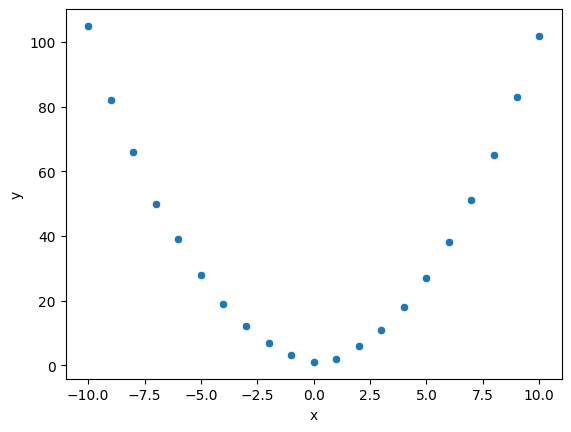

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df['x'], y= df['y'])
plt.show()

In [35]:
x_train, x_test, y_train, y_test= train_test_split(df['x'], df['y'], random_state= 42, test_size= 0.2)

In [36]:
x_train.values

array([-5,  1, -7,  8,  6,  3, -8, -1, 10, -6,  2, -3,  0,  4,  9, -4])

In [37]:
#it is a non linear. so applying polynomial here
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pf= PolynomialFeatures(degree= 2, include_bias= True)
pf.set_output(transform= 'pandas')

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [38]:
x_train_pf= pf.fit_transform(np.reshape(x_train.values, (-1, 1)))
x_test_pf= pf.transform(np.reshape(x_test.values, (-1, 1)))

In [39]:
x_train_pf

,1,x0,x0^2
0,1.0,-5.0,25.0
1,1.0,1.0,1.0
2,1.0,-7.0,49.0
3,1.0,8.0,64.0
4,1.0,6.0,36.0
5,1.0,3.0,9.0
6,1.0,-8.0,64.0
7,1.0,-1.0,1.0
8,1.0,10.0,100.0
9,1.0,-6.0,36.0


In [40]:
lr= LinearRegression()
lr.fit(x_train_pf, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [54]:
lr.intercept_

np.float64(1.996283603826619)

In [41]:
y_pred= lr.predict(x_test_pf)

In [42]:
from sklearn.metrics import r2_score
r2_score(y_true= y_test, y_pred= y_pred)

0.9985326826481541

In [52]:
x_train_pf.values.ravel()

array([  1.,  -5.,  25.,   1.,   1.,   1.,   1.,  -7.,  49.,   1.,   8.,
        64.,   1.,   6.,  36.,   1.,   3.,   9.,   1.,  -8.,  64.,   1.,
        -1.,   1.,   1.,  10., 100.,   1.,  -6.,  36.,   1.,   2.,   4.,
         1.,  -3.,   9.,   1.,   0.,   0.,   1.,   4.,  16.,   1.,   9.,
        81.,   1.,  -4.,  16.])

Use Pipeline when transformations apply to the whole dataset sequentially

 Use ColumnTransformer when different columns need different transformations

In [146]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline= Pipeline(
    steps=[
        ('clf1', PolynomialFeatures(degree= 2)),
        ('clf2',StandardScaler() ),
        ('model', SGDRegressor(loss="squared_error",
        max_iter=2000,
        eta0=0.01,                 # small learning rate
        learning_rate="invscaling",
    ))
    ]
)

In [150]:
pipeline.fit(x_train.values.reshape(-1, 1), y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clf1', ...), ('clf2', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [154]:
y_pred=pipeline.predict(x_test.values.reshape(-1,1))   #here transform is automatically done

In [155]:
y_pred

array([101.52790289,  50.83007451,  26.99214597,  82.65107559,
         6.14439185])

In [156]:
r2_score(y_true= y_test, y_pred= y_pred)

0.9979087124963782